# Creating a random circuit
The code below defines a function that creates a random circuit given the number of qubits and the circuit depth.

In [1]:
import random
from qiskit import QuantumCircuit
from quantum_optimiser.multimetric import rewrite
from quantum_optimiser import integration
import pyzx 

%load_ext autoreload
%autoreload 2
    

one_qubit_gates = ["h", "s", "sdg", "t", "tdg", "x", "z"]
two_qubit_gates = ["cx","cz",]

def random_circuit_generator(max_qubits, max_depth):
    qubits = random.randint(2, max_qubits)
    depth = random.randint(2, max_depth)
    qc = QuantumCircuit(qubits)

          
    for i in range(depth):
        if random.random() < 0.6:
            q = random.randrange(qubits)
            gate = random.choice(one_qubit_gates)
            getattr(qc, gate)(q)
        else:
            q1, q2 = random.sample(range(qubits), 2)
            gate = random.choice(two_qubit_gates)
            getattr(qc, gate)(q1, q2)

    return qc


qc = random_circuit_generator(100,100)
qc.draw("mpl")
diagram = integration.qiskit_to_pyzx(qc)
pyzx.draw(diagram, labels = "true")

for i in range (0,200):
    print(i)
    print(rewrite.get_applicable_rules(diagram,i))

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\sanja\quantum-circuit-optimiser\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanja\quantum-circuit-optimiser\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen 

0
['lcomp', 'pivot', 'insert_hadamard_pair']
1
['lcomp', 'pivot', 'insert_hadamard_pair']
2
['lcomp', 'pivot', 'insert_hadamard_pair']
3
['lcomp', 'pivot', 'insert_hadamard_pair']
4
['lcomp', 'pivot', 'insert_hadamard_pair']
5
['lcomp', 'pivot', 'insert_hadamard_pair']
6
['lcomp', 'pivot', 'insert_hadamard_pair']
7
['lcomp', 'pivot', 'insert_hadamard_pair']
8
['lcomp', 'pivot', 'insert_hadamard_pair']
9
['lcomp', 'pivot', 'insert_hadamard_pair']
10
['lcomp', 'pivot', 'insert_hadamard_pair']
11
['lcomp', 'pivot', 'insert_hadamard_pair']
12
['lcomp', 'pivot', 'insert_hadamard_pair']
13
['lcomp', 'pivot', 'insert_hadamard_pair']
14
['lcomp', 'pivot', 'insert_hadamard_pair']
15
['lcomp', 'pivot', 'insert_hadamard_pair']
16
['lcomp', 'pivot', 'insert_hadamard_pair']
17
['lcomp', 'pivot', 'insert_hadamard_pair']
18
['lcomp', 'pivot', 'insert_hadamard_pair']
19
['lcomp', 'pivot', 'insert_hadamard_pair']
20
['lcomp', 'pivot', 'insert_hadamard_pair']
21
['lcomp', 'pivot', 'insert_hadamard_pair'

In [ ]:
%load_ext autoreload
%autoreload 2

from qiskit.circuit.random import random_circuit
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.multimetric import loss
from quantum_optimiser.multimetric import simulated_annealing
from quantum_optimiser.multimetric import rewrite

from qiskit import transpile
import pyzx
from IPython.display import display





best_circuit, best_diagram, best_cost, _ = simulated_annealing.simulated_annealing_zx(
                circuit=qc,
                cost_function=loss.log_weighted_loss,
                get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=100,
                max_no_improvement=50,
            )

pyzx.draw(diagram, labels = "true")
pyzx.draw(best_diagram, labels = "true")
for i in range (0,200):
    print(i)
    print(rewrite.get_applicable_rules(best_diagram,i))
    
circ = integration.pyzx_to_qiskit(best_diagram)
circ.draw("mpl")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
our baseline is: {'q': 26, 'g2': 12, 'g': 32, 't': 5, 'd': 5, 'swap': 0}
had to go here again


KeyboardInterrupt: 


KeyboardInterrupt



# Evaluating the optimiser
The code below generates 10 random circuits of the same size, and prints out the average decrease in each cost function as well as the average decrease of each metric

In [4]:
import numpy as np

def get_metrics(circuit):
    return {
        "qubits": metrics.circuit_qubit_count(circuit),
        "two_qubit": metrics.circuit_two_qubit_gate_count(circuit),
        "gates": metrics.circuit_gate_count(circuit),
        "depth": metrics.circuit_depth(circuit),
        "t": metrics.circuit_t_gate_count(circuit),
    }

def evaluate_once(circuit, loss_fn):
    before_m = get_metrics(circuit,hardware)
    before_L = loss_fn(circuit)
    optimised_circuit, optimised_diagram, optimised_cost, _ =  simulated_annealing.simulated_annealing_zx(
                circuit=circuit,
                cost_function=loss_fn,
                get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=500,
                max_no_improvement=50,   
            )
    after_m = get_metrics(optimised_circuit)
    after_L = optimised_cost

    dL = before_L - after_L
    dm = {k: before_m[k] - after_m[k] for k in before_m}
    return dL, dm

def evaluate(n_circuits=10, qubits=100, depth=100):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }

    cost_deltas = {name: [] for name in functions}
    metric_deltas = {name: [] for name in functions}
    
    circuits = [random_circuit_generator(qubits, depth) for i in range(n_circuits)]
    for qc in circuits:
        for name,L in functions.items():
            dL, dm = evaluate_once(qc, L)
            cost_deltas[name].append(dL)
            metric_deltas[name].append(dm)

    print(f"\nBenchmark over {n_circuits} circuits | qubits={qubits} depth={depth}\n")

    for name in functions:
        avg_dL = float(np.mean(cost_deltas[name]))
        print(name)
        print(f"Avg cost decrease: {avg_dL:.4f}")

        keys = metric_deltas[name][0].keys()
        avg_metrics = {k: float(np.mean([m[k] for m in metric_deltas[name]])) for k in keys}
        for k, v in avg_metrics.items():  
            print(f"  Avg {k} decrease: {v:.4f}")
        print()


evaluate()

TypeError: get_metrics() takes 1 positional argument but 2 were given

In [3]:
from joblib import Parallel, delayed
import numpy as np

from quantum_optimiser.hardware_aware import hardware_map
from quantum_optimiser.hardware_aware import hardwares
hardware=hardwares.sherbrooke

def get_metrics(circuit,hardware):
    return {
        "qubits": metrics.circuit_qubit_count(circuit),
        "two_qubit": metrics.circuit_two_qubit_gate_count(circuit,hardware),
        "gates": metrics.circuit_gate_count(circuit,hardware),
        "depth": metrics.circuit_depth(circuit),
        "t": metrics.circuit_t_gate_count(circuit),
    }

def evaluate_once(circuit, loss_fn):
    before_m = get_metrics(circuit,hardware)
    before_L = loss_fn(circuit,hardware)
    optimised_circuit, optimised_diagram, optimised_cost, _ = simulated_annealing.simulated_annealing_zx(
        circuit=circuit,
        cost_function=loss_fn,
        get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
        initial_temp=100.0,
        cooling_rate=0.95,
        max_iterations=300,
        max_no_improvement=10,
        hardware=hardwares.sherbrooke
    )
    after_m = get_metrics(optimised_circuit,hardware)
    after_L = optimised_cost
    dL = before_L - after_L
    dm = {k: before_m[k] - after_m[k] for k in before_m}
    return dL, dm

def evaluate_once_wrapper(circuit, name):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }
    dL, dm = evaluate_once(circuit, functions[name])
    return name, dL, dm

def evaluate(n_circuits=10, depth=100,hardware=None):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }
    
    qubits = hardware.qubits  # match the hardware map
    circuits = [random_circuit_generator(qubits, depth) for _ in range(n_circuits)]
    
    tasks = [
        (qc, name)
        for qc in circuits
        for name in functions
    ]
    results = Parallel(n_jobs=10, backend="threading", verbose=10)(
    delayed(evaluate_once_wrapper)(qc, name)
    for qc, name in tasks)
    
    
    cost_deltas = {name: [] for name in functions}
    metric_deltas = {name: [] for name in functions}
    
    for name, dL, dm in results:
        cost_deltas[name].append(dL)
        metric_deltas[name].append(dm)
    
    print(f"\nBenchmark over {n_circuits} circuits | qubits={qubits} depth={depth}\n")
    for name in functions:
        avg_dL = float(np.mean(cost_deltas[name]))
        print(name)
        print(f"Avg cost decrease: {avg_dL:.4f}")
        keys = metric_deltas[name][0].keys()
        avg_metrics = {k: float(np.mean([m[k] for m in metric_deltas[name]])) for k in keys}
        for k, v in avg_metrics.items():
            print(f"  Avg {k} decrease: {v:.4f}")
        print()

hardware=hardwares.sherbrooke
print(type(hardware))

evaluate(hardware=hardware)

<class 'quantum_optimiser.hardware_aware.hardware_map.hardware_map'>


NameError: name 'loss' is not defined

In [ ]:
from quantum_optimiser import optimiser
from quantum_optimiser.optimiser import evaluate



from quantum_optimiser.hardware_aware import hardwares
hardware = hardwares.sherbrooke

evaluate(n_circuits=1, depth=50, hardware=hardware)

In [13]:
import pyzx
from qiskit.circuit.random import random_circuit
from quantum_optimiser.multimetric import metrics

circuit = random_circuit_generator (100,100)
print("Before:", metrics.circuit_two_qubit_gate_count(circuit))

diagram = integration.qiskit_to_pyzx(circuit)
pyzx.full_reduce(diagram)
result = integration.pyzx_to_qiskit(diagram)
print("After full_reduce:", metrics.circuit_two_qubit_gate_count(result))

Before: 13
After full_reduce: 13


In [2]:
from quantum_optimiser.multimetric import loss, simulated_annealing
from quantum_optimiser.hardware_aware import hardwares
import pyzx as zx
from qiskit import transpile

hardware = hardwares.sherbrooke
circuit = random_circuit_generator (100,100)
print("Initial stats:", loss._compute_stats(circuit))

optimised, diagram, _, history = simulated_annealing.simulated_annealing_zx(
    circuit=circuit,
    cost_function=loss.log_weighted_loss,
    get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
    initial_temp=100.0,
    cooling_rate=0.99,
    max_iterations=500,
    max_no_improvement=50,
    hardware=None
)

print("Final stats:", loss._compute_stats(optimised))
print("Iterations run:", len(history))
print("Accepted moves:", sum(1 for h in history if h['accepted'])) 
print("Cost went from:", history[0]['current_cost'], "to:", history[-1]['best_cost'])

try:
    diagram_fr = integration.qiskit_to_pyzx(circuit)
    zx.simplify.full_reduce(diagram_fr)
    full_reduce_circuit = integration.pyzx_to_qiskit(diagram_fr)
    print("full_reduce stats:", loss._compute_stats(full_reduce_circuit))
except Exception as e:
    print("full_reduce failed:", e)

qiskit_optimised = transpile(circuit, basis_gates=["h","s","sdg","t","tdg","x","z","cx","cz"], optimization_level=3)
print("Qiskit level 3:", loss._compute_stats(qiskit_optimised))


from qiskit.quantum_info import Operator
import numpy as np


NameError: name 'random_circuit_generator' is not defined

In [15]:
from qiskit import QuantumCircuit
from qiskit import transpile

# Build a circuit with obviously cancellable two-qubit gates
qc = QuantumCircuit(3)
qc.cx(0, 1)
qc.cx(0, 1)  # cancels with above
qc.cx(1, 2)
qc.cx(1, 2)  # cancels with above
qc.h(0)
qc.t(1)
qc.cx(0, 1)
qc.cx(0, 1)  # cancels with above

print("Initial:", loss._compute_stats(qc))

# full_reduce
diagram = integration.qiskit_to_pyzx(qc)
#zx.simplify.full_reduce(diagram)
full_reduce_result = integration.pyzx_to_qiskit(diagram)
print("full_reduce:", loss._compute_stats(full_reduce_result))

# SA
optimised, _, _, history = simulated_annealing.simulated_annealing_zx(
    circuit=qc,
    cost_function=loss.log_weighted_loss,
    get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
    initial_temp=100.0,
    cooling_rate=0.95,
    max_iterations=500,
    max_no_improvement=50,
    hardware=hardware
)
qiskit_optimised = transpile(qc, basis_gates=["h","s","sdg","t","tdg","x","z","cx","cz"], optimization_level=3)
print("Qiskit level 3:", loss._compute_stats(qiskit_optimised))

print("SA:", loss._compute_stats(optimised))

Initial: {'q': 3, 'g2': 6, 'g': 8, 't': 1, 'd': 7}
full_reduce: {'q': 3, 'g2': 6, 'g': 8, 't': 1, 'd': 7}
0 216
Qiskit level 3: {'q': 2, 'g2': 0, 'g': 2, 't': 1, 'd': 1}
SA: {'q': 1, 'g2': 0, 'g': 2, 't': 1, 'd': 2}


In [83]:
circuit = random_circuit_generator (100,100)
print("First stats:", loss._compute_stats(circuit))

diagram = integration.qiskit_to_pyzx(circuit)
zx.simplify.to_graph_like(diagram)
circuit = integration.pyzx_to_qiskit(diagram)
print("Final stats:", loss._compute_stats(circuit))


First stats: {'q': 29, 'g2': 14, 'g': 26, 't': 2, 'd': 3}
Final stats: {'q': 59, 'g2': 14, 'g': 148, 't': 2, 'd': 5}


In [93]:
circuit = random_circuit_generator(10, 20)
print("Original:", loss._compute_stats(circuit))

diagram = integration.qiskit_to_pyzx(circuit)


Original: {'q': 8, 'g2': 4, 'g': 17, 't': 1, 'd': 5}


In [94]:
from pyzx.circuit import Circuit

pyzx_circuit = pyzx.extract.extract_circuit(diagram.copy(), optimize_czs=False, optimize_cnots=0, quiet=True)
pyzx_circuit = Circuit.to_basic_gates(pyzx_circuit)
pyzx_circuit = Circuit.split_phase_gates(pyzx_circuit)
qasm_circuit = Circuit.to_qasm(pyzx_circuit)
qasm_circuit = QuantumCircuit.from_qasm_str(qasm_circuit)
circuit = transpile(qasm_circuit,basis_gates=["h","s","sdg","t","tdg","x","z","cx","cz"],optimization_level=0)
print("Roundtrip:", loss._compute_stats(circuit))

Roundtrip: {'q': 8, 'g2': 4, 'g': 30, 't': 1, 'd': 8}


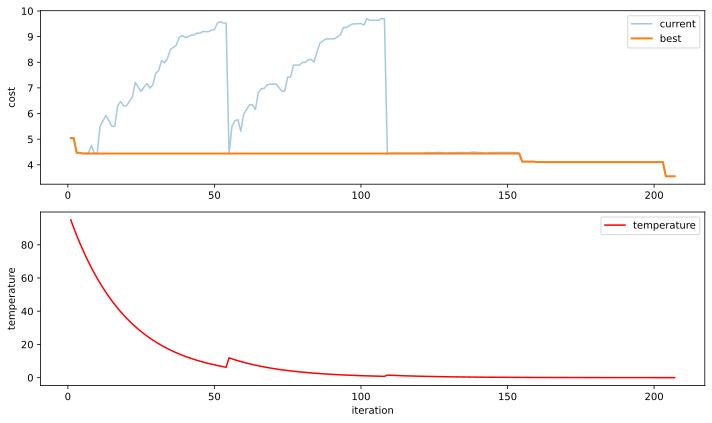

In [41]:
def plot_history(history):
    import matplotlib.pyplot as plt
    iterations = [h['iteration'] for h in history]
    current = [h['current_cost'] for h in history]
    best = [h['best_cost'] for h in history]
    temp = [h['temperature'] for h in history]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    ax1.plot(iterations, current, alpha=0.4, label='current')
    ax1.plot(iterations, best, label='best', linewidth=2)
    ax1.set_ylabel('cost')
    ax1.legend()
    ax2.plot(iterations, temp, color='red', label='temperature')
    ax2.set_ylabel('temperature')
    ax2.set_xlabel('iteration')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)